In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

In [2]:
np.random.seed(42)
customers = pd.DataFrame({
    'customer_id' : range(1, 201),
    'age' : np.random.randint(18,70,200),
    'country' : np.random.choice(['USA', 'Canada', 'UK'], 200)
})

customers.head()

,customer_id,age,country
0,1,56,Canada
1,2,69,UK
2,3,46,USA
3,4,32,Canada
4,5,60,USA


In [3]:
products = pd.DataFrame({
    'product_id' : range(1,21),
    'category' : np.random.choice(
        ['Electronics', 'Clothing', 'Home'], 20
    ),
    'price' : np.random.randint(20, 500, 20)
})

products.head()

,product_id,category,price
0,1,Electronics,82
1,2,Electronics,209
2,3,Clothing,144
3,4,Home,169
4,5,Electronics,333


In [4]:
orders = pd.DataFrame({
    'order_id' : range(1, 1001),
    'customer_id' : np.random.randint(1, 201, 1000),
    'product_id' : np.random.randint(1, 21, 1000),
    'quantity' : np.random.randint(1, 5, 1000)
})

orders.head()

,order_id,customer_id,product_id,quantity
0,1,103,6,4
1,2,196,18,2
2,3,6,10,2
3,4,109,4,3
4,5,116,9,3


In [5]:
conn = sqlite3.connect('sales.db')

In [7]:
customers.to_sql('customers', conn, if_exists = 'replace', index = False)
products.to_sql('products', conn, if_exists = 'replace', index = False)
orders.to_sql('orders', conn, if_exists = 'replace', index = False)

1000

In [8]:
query = """
SELECT *
FROM orders o
JOIN customers c
ON o.customer_id = c.customer_id
"""

pd.read_sql(query, conn)

,order_id,customer_id,product_id,quantity,customer_id,age,country
0,1,103,6,4,103,42,Canada
1,2,196,18,2,196,69,Canada
2,3,6,10,2,6,25,USA
3,4,109,4,3,109,25,Canada
4,5,116,9,3,116,52,USA
...,...,...,...,...,...,...,...
995,996,29,9,2,29,61,Canada
996,997,109,19,4,109,25,Canada
997,998,98,9,2,98,58,UK
998,999,37,3,1,37,64,USA


In [9]:
query = """
SELECT o.order_id,
       c.country,
       p.category,
       p.price,
       o.quantity,
       (p.price * o.quantity) AS revenue
FROM orders o
JOIN customers c
ON o.customer_id = c.customer_id
JOIN products p
ON o.product_id = p.product_id
"""

sales = pd.read_sql(query, conn)

sales.head()

,order_id,country,category,price,quantity,revenue
0,1,Canada,Electronics,77,4,308
1,2,Canada,Home,79,2,158
2,3,USA,Home,189,2,378
3,4,Canada,Home,169,3,507
4,5,USA,Clothing,199,3,597


In [12]:
#Which country contributes the most revenue?
query = """
SELECT c.country,
       SUM(p.price * o.quantity) AS total_revenue
FROM orders o
JOIN customers c
ON o.customer_id = c.customer_id
JOIN products p
ON o.product_id = p.product_id
GROUP BY c.country
ORDER BY total_revenue DESC
"""

pd.read_sql(query, conn)

,country,total_revenue
0,Canada,182261
1,USA,165834
2,UK,158910


In [17]:
#Which category contributes the most revenue?
query = """
SELECT p.category,
       SUM(p.price * o.quantity) AS revenue
FROM orders o
JOIN products p
ON o.product_id = p.product_id
GROUP BY p.category
ORDER BY revenue DESC
"""
category_revenue = pd.read_sql(query, conn)
category_revenue

,category,revenue
0,Home,189174
1,Clothing,168830
2,Electronics,149001


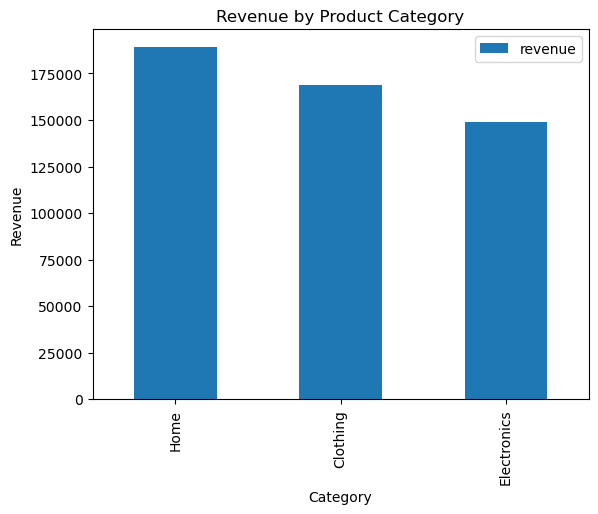

<Figure size 640x480 with 0 Axes>

In [21]:
category_revenue.plot(
    x = "category",
    y = 'revenue',
    kind = 'bar'
)

plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Revenue')

plt.show()
plt.savefig(
    "/Users/godricccc/Documents/sales-analytics-project/visuals/revenue_by_category.png"
)

In [15]:
#TOP 20 customers
query = """
SELECT c.customer_id,
       c.country,
       SUM(p.price * o.quantity) AS total_spent
FROM orders o
JOIN customers c
ON o.customer_id = c.customer_id
JOIN products p
ON o.product_id = p.product_id
GROUP BY c.customer_id, c.country
ORDER BY total_spent DESC
LIMIT 20
"""
pd.read_sql(query, conn)

,customer_id,country,total_spent
0,179,Canada,8719
1,47,USA,8384
2,109,Canada,6239
3,111,Canada,6079
4,69,Canada,5879
5,104,USA,5735
6,118,Canada,5673
7,90,UK,5587
8,92,USA,5428
9,113,UK,5318
